In [2]:
import os
import sys

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt
import gc

lib_decompre = "/var/home/dotamthuc/Works/Compress3DGS/Differentiable3DPC-Decompression-and-Rendering/"
sys.path.insert(0, lib_decompre)

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene
import decompress_render


lib_svraster = "/var/home/dotamthuc/Works/Compress3DGS/Baselines/svraster"
sys.path.insert(0, lib_svraster)
from src.sparse_voxel_model import SparseVoxelModel

np.set_printoptions(precision=3, suppress=True)

torch.cuda.set_per_process_memory_fraction(0.9, 0)

/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/

# 01 

In [2]:
def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=3,
        ss=1.5,
        white_background=False,
        black_background=False,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    #morton_code
    geometry_info["morton_code_tensor"] = voxel_model_frame.octpath.clone().detach()

    #vox_roots
    vox_roots = (voxel_model_frame.vox_center - 0.5 * voxel_model_frame.vox_size)
    geometry_info["vox_roots_tensor"] = vox_roots.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()

    # Geometry conners
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame._geo_grid_pts.clone().detach()

    # Colors
    if load_attribute_field:
        # SH0 = 0.28209479177387814
        # static_color  = (voxel_model_frame._sh0 * SH0 + 0.5).clone().detach()
        # static_color[static_color<0.0] = 0.0
        # geometry_info["vox_params_color_tensor"] = static_color
        geometry_info["vox_params_color_tensor"] = torch.concat([
            voxel_model_frame.sh0[:, None, :], voxel_model_frame.shs[:, :, :]
        ], dim=1)


    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


def resize_rendering(render, size, mode='bilinear', align_corners=False):
    return torch.nn.functional.interpolate(
        render[None], size=size, mode=mode, align_corners=align_corners, antialias=True)[0]


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.0, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):
        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        # if voxel_attribute.shape != (self.num_voxels, 3):
        #     raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()


        return rendered_image



SH_C0 = 0.28209479177387814
SH_C1 = 0.4886025119029199
SH_C2 = [
    1.0925484305920792,
    -1.0925484305920792,
    0.31539156525252005,
    -1.0925484305920792,
    0.5462742152960396
]
SH_C3 = [
    -0.5900435899266435,
    2.890611442640554,
    -0.4570457994644658,
    0.3731763325901154,
    -0.4570457994644658,
    1.445305721320277,
    -0.5900435899266435
]
def computeColorFromSH(
        input_dir, coefs_mask,
    ):

    dir_norm = np.sqrt(np.sum((input_dir**2)))
    # print(f"dir={dir} dir_norm={dir_norm}")
    input_dir = input_dir / dir_norm
    # print(f"Dir={input_dir}")

    # // The implementation is loosely based on code for
    # // "Differentiable Point-Based Radiance Fields for
    # // Efficient View Synthesis" by Zhang et al. (2022)
    sh = coefs_mask[1:, :]
    sh0 = coefs_mask[0, :]

    # DEG 0
    result = SH_C0 * sh0

    #DEG 1
    x,y,z = input_dir[0], input_dir[1], input_dir[2]
    result = result - SH_C1 * y * sh[0] + SH_C1 * z * sh[1] - SH_C1 * x * sh[2]

    #DEG 2
    xx = x * x
    yy = y * y
    zz = z * z
    xy = x * y
    yz = y * z
    xz = x * z
    result = result + \
        SH_C2[0] * xy * sh[3] + \
        SH_C2[1] * yz * sh[4] + \
        SH_C2[2] * (2.0 * zz - xx - yy) * sh[5] + \
        SH_C2[3] * xz * sh[6] + \
        SH_C2[4] * (xx - yy) * sh[7]
    
    # DEG 3
    result = result + \
        SH_C3[0] * y * (3.0 * xx - yy) * sh[8] + \
        SH_C3[1] * xy * z * sh[9] + \
        SH_C3[2] * y * (4.0 * zz - xx - yy) * sh[10] + \
        SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * sh[11] + \
        SH_C3[4] * x * (4.0 * zz - xx - yy) * sh[12] + \
        SH_C3[5] * z * (xx - yy) * sh[13] + \
        SH_C3[6] * x * (xx - 3.0 * yy) * sh[14] 

    result = result
    # result[result<=0] = 0.0
    return result


In [3]:
scene_sourse = "/var/home/dotamthuc/Works/Compress3DGS/Data/mip-nerf-360/{}/".format("bicycle")
scene_dataset = Scene(
    scene_sourse, image_dir_name="images",
    res_downscale=0.0, res_width=1600,
    test_view_every=8,
    load_test_only=True
)
test_views = scene_dataset.get_test_views()
test_one_view = scene_dataset.get_test_views()[0]

Read dataset in COLMAP format.
Done reading and creating views: 0 train views and 25 encoding views


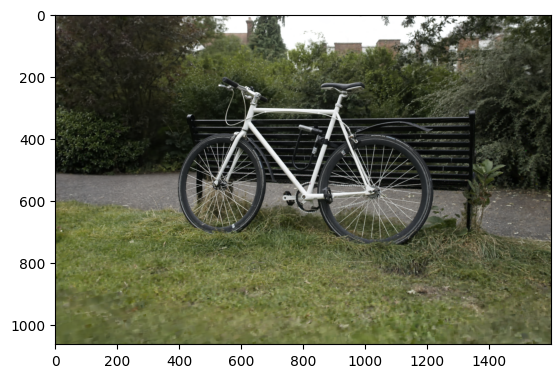

In [5]:

checkpoint = "/var/home/dotamthuc/Works/Compress3DGS/Results/SVRaster-small/mip-nerf-360/bicycle/rate00/checkpoints/iter030000_model.pt"
ref_denfield= DensityField(checkpoint)

####
voxel_morton_code = ref_denfield.voxel_morton_code.detach().cpu().numpy()
voxel_position = ref_denfield.voxel_position.detach().cpu().numpy()
voxel_size = ref_denfield.voxel_size.detach().cpu().numpy()
voxel2corner = ref_denfield.voxel2corner.detach().cpu().numpy()
corner_geo_params = ref_denfield.corner_geo_params.detach().cpu().numpy()
num_voxels = ref_denfield.num_voxels
voxel_attribute_field = ref_denfield.voxel_attribute_field.detach().cpu().numpy()

tensor_img_target = ref_denfield.apply_phi(test_views[0]).detach()
img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
plt.imshow(img_target)
plt.show()

In [6]:
len(test_views)

25

# 02 - No Transform

In [ ]:
U = np.eye(48)
X_transformed = (voxel_attribute_field.reshape(-1, 48) @ U)

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 48):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs] = X_transformed[:, :ncoefs]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=12.911361364335615
ncoefs=2, psnr=14.751704070831922
ncoefs=3, psnr=23.650882015123234
ncoefs=4, psnr=23.850907961470135
ncoefs=5, psnr=24.094777027803715
ncoefs=6, psnr=24.344556403503603
ncoefs=7, psnr=24.52598046899778
ncoefs=8, psnr=24.711349027745577
ncoefs=9, psnr=24.90443062976683
ncoefs=10, psnr=25.10284700974051
ncoefs=11, psnr=25.311215147724155
ncoefs=12, psnr=25.56308577570801
ncoefs=13, psnr=25.67655613324302
ncoefs=14, psnr=25.773431202340674
ncoefs=15, psnr=25.85934962517808
ncoefs=16, psnr=25.941203541117254
ncoefs=17, psnr=26.00365840959945
ncoefs=18, psnr=26.06153197451247
ncoefs=19, psnr=26.255752298645
ncoefs=20, psnr=26.450706601443343
ncoefs=21, psnr=26.6231381156653
ncoefs=22, psnr=26.91225548892581
ncoefs=23, psnr=27.191964722173406
ncoefs=24, psnr=27.42027301466183
ncoefs=25, psnr=27.644509549709095
ncoefs=26, psnr=27.865056860509945
ncoefs=27, psnr=28.07996619543523
ncoefs=28, psnr=28.365015803202365
ncoefs=29, psnr=28.628719723405524
ncoefs=30,

/tmp/ipykernel_3812645/2084945631.py:35: RuntimeWarning: divide by zero encountered in log10
  psnr.append(-10 * np.log10(np.mean(list_mse)))


# 03 - KLT on sh coefs

In [14]:
XtX = voxel_attribute_field.reshape(-1, 48).T @ voxel_attribute_field.reshape(-1, 48)
# # C = np.cov(X, rowvar=False)
# # S, U = np.linalg.eig(C)
U, S, V = np.linalg.svd(XtX)
X_transformed = (voxel_attribute_field.reshape(-1, 48) @ U)

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 48):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs] = X_transformed[:, :ncoefs]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=21.972398622111665
ncoefs=2, psnr=23.575235472983724
ncoefs=3, psnr=23.829080270645782
ncoefs=4, psnr=24.51367828291014
ncoefs=5, psnr=24.908408756128615
ncoefs=6, psnr=25.170450106627985
ncoefs=7, psnr=25.83125078858121
ncoefs=8, psnr=26.462576021165557
ncoefs=9, psnr=26.71521761897221
ncoefs=10, psnr=27.01310017628987
ncoefs=11, psnr=28.725156553997024
ncoefs=12, psnr=29.844202355557226
ncoefs=13, psnr=31.264941354603927
ncoefs=14, psnr=32.500917612690195
ncoefs=15, psnr=35.8578090236943
ncoefs=16, psnr=36.412628689519835
ncoefs=17, psnr=36.97468000262214
ncoefs=18, psnr=37.177723248065114
ncoefs=19, psnr=37.49570318486034
ncoefs=20, psnr=38.01592380440998
ncoefs=21, psnr=38.407835220705614
ncoefs=22, psnr=38.66278866289964
ncoefs=23, psnr=39.577231528062825
ncoefs=24, psnr=40.101142062226735
ncoefs=25, psnr=40.85876016058968
ncoefs=26, psnr=41.38698138231666
ncoefs=27, psnr=41.95543632734626
ncoefs=28, psnr=42.88326939426375
ncoefs=29, psnr=44.314122167358576
ncoefs=3

# 03 - View dependence

In [24]:
from sklearn.cluster import KMeans


list_dir = []
for view_i, view in enumerate(test_views):
    print(f"Done view_i={view_i}")

    cam_pos = view.view2world[:3, 3]
    All_direction = (voxel_position - cam_pos[np.newaxis, :].numpy())
    All_direction = All_direction / (All_direction**2).sum(axis=1, keepdims=True)

    kmeans = KMeans(n_clusters=64, random_state=0, n_init='auto')
    kmeans.fit(All_direction)

    list_dir.append(kmeans.cluster_centers_)



Done view_i=0
Done view_i=1
Done view_i=2
Done view_i=3
Done view_i=4
Done view_i=5
Done view_i=6
Done view_i=7
Done view_i=8
Done view_i=9
Done view_i=10
Done view_i=11
Done view_i=12
Done view_i=13
Done view_i=14
Done view_i=15
Done view_i=16
Done view_i=17
Done view_i=18
Done view_i=19
Done view_i=20
Done view_i=21
Done view_i=22
Done view_i=23
Done view_i=24


In [25]:
list_all_view_dir = np.concatenate(list_dir)


In [27]:


transformM = []
i=0
for dir in list_all_view_dir:
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    transformM.append(out_dir)
    
transformM = np.array(transformM)
print(f"transformM.shape={transformM.shape}")
transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(len(list_all_view_dir)*3, 16*3)
print(f"transformM.shape={transformM.shape}")

transformM.shape=(1600, 16, 3, 3)
transformM.shape=(4800, 48)


In [21]:
# temp_colors = voxel_attribute_field.reshape(-1, 48) @ transformM[:2*3, :48].T
# temp_colors = temp_colors.reshape(-1, 2, 3) + 0.5

# for i in range(2):
#     static_color = torch.from_numpy(temp_colors[:, i, :].astype(np.float32)).cuda()
#     tensor_img_target = ref_denfield.apply_phi_with_F(static_color, test_views[0]).detach()
#     img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
#     plt.imshow(img_target)
#     plt.show()



In [28]:
M = transformM[:, :]
MtM = (M.T @ M)
U, S, Vt = np.linalg.svd(MtM)
MtT_sqrt_inv = U @ np.diag(1/np.sqrt(S)) @ Vt

# U =  U[:, np.argsort(S)]
transform = MtM @ MtT_sqrt_inv
inv_transform = MtT_sqrt_inv

X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform)


XtX = X_transformed.T @ X_transformed
# # C = np.cov(X, rowvar=False)
# # S, U = np.linalg.eig(C)
U, S, V = np.linalg.svd(XtX)
X_transformed_2nd = (X_transformed @ U)



In [29]:

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 48):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs] = X_transformed_2nd[:, :ncoefs]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T @ inv_transform).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=22.094348394687586
ncoefs=2, psnr=23.72915611000743
ncoefs=3, psnr=24.004661568930146
ncoefs=4, psnr=24.521568756026557
ncoefs=5, psnr=24.995659383910965
ncoefs=6, psnr=25.463352432465495
ncoefs=7, psnr=26.017546144653473
ncoefs=8, psnr=26.809159725891924
ncoefs=9, psnr=27.726304814984687
ncoefs=10, psnr=29.275562272243207
ncoefs=11, psnr=30.402053691910798
ncoefs=12, psnr=31.755168567999895
ncoefs=13, psnr=32.584314498206055
ncoefs=14, psnr=34.5354619621426
ncoefs=15, psnr=36.80884529146253
ncoefs=16, psnr=37.04550288755708
ncoefs=17, psnr=37.18485545397032
ncoefs=18, psnr=37.607046001987804
ncoefs=19, psnr=37.91229116818347
ncoefs=20, psnr=38.26234559070611
ncoefs=21, psnr=38.863002237390816
ncoefs=22, psnr=39.6136777208416
ncoefs=23, psnr=40.24473530779037
ncoefs=24, psnr=40.77097137249963
ncoefs=25, psnr=41.69586320108665
ncoefs=26, psnr=42.589832453438575
ncoefs=27, psnr=43.9168880064355
ncoefs=28, psnr=44.58962849834662
ncoefs=29, psnr=45.23067429676752
ncoefs=30, 

# END

Text(0.5, 1.0, 'Bicycle Scene')

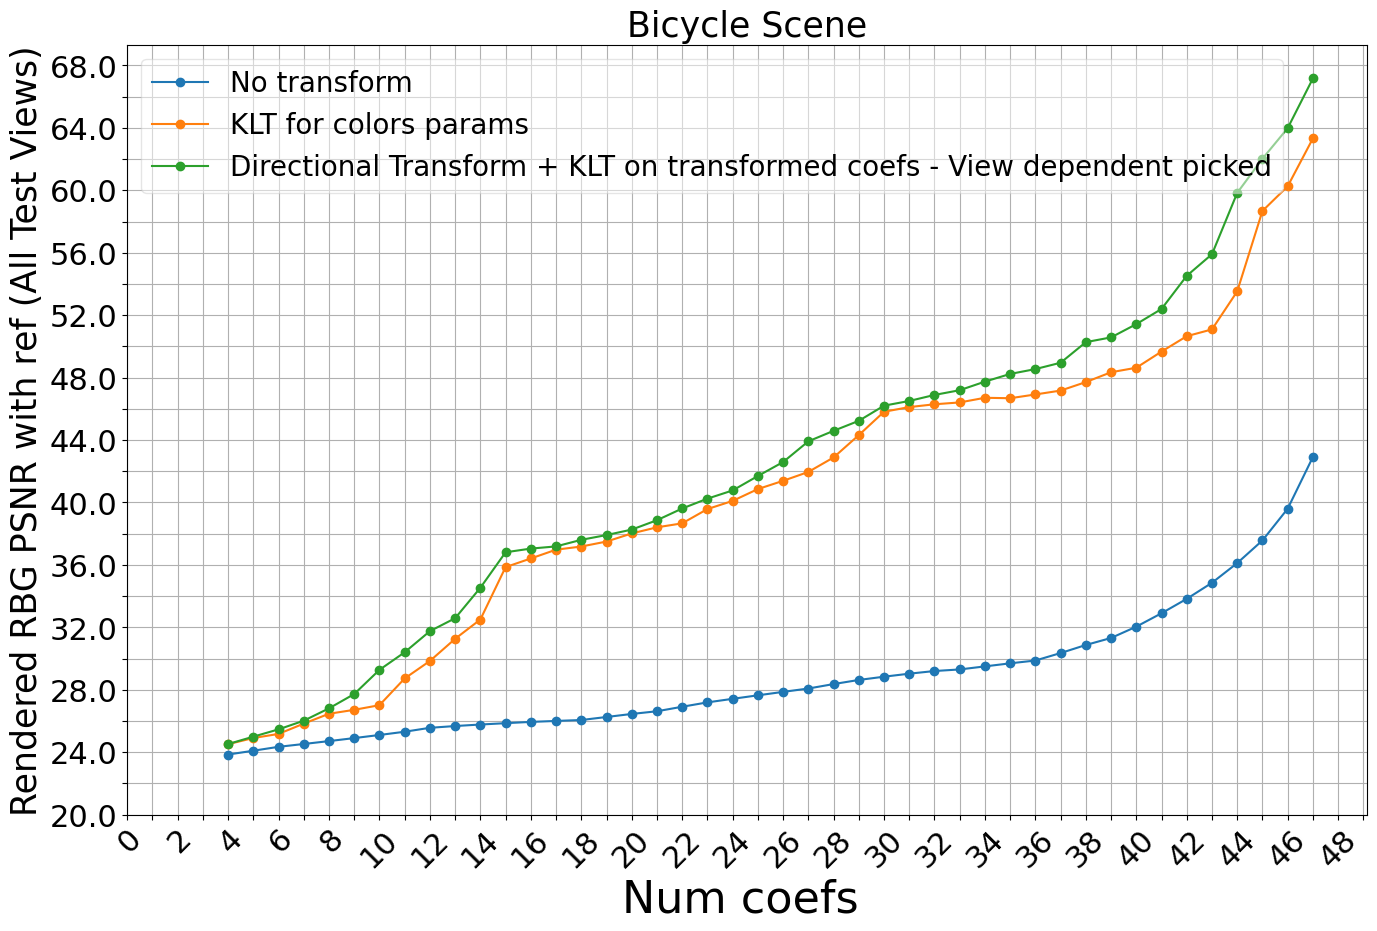

In [7]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 10))


## BASELINE 
psnr=[12.911361364335615, 14.751704070831922, 23.650882015123234, 23.850907961470135, 24.094777027803715, 24.344556403503603, 24.52598046899778, 24.711349027745577, 24.90443062976683, 25.10284700974051, 25.311215147724155, 25.56308577570801, 25.67655613324302, 25.773431202340674, 25.85934962517808, 25.941203541117254, 26.00365840959945, 26.06153197451247, 26.255752298645, 26.450706601443343, 26.6231381156653, 26.91225548892581, 27.191964722173406, 27.42027301466183, 27.644509549709095, 27.865056860509945, 28.07996619543523, 28.365015803202365, 28.628719723405524, 28.837165541882243, 29.030773519153577, 29.200985201911337, 29.302052613628526, 29.49777828770825, 29.69429292349625, 29.87409564044825, 30.35294405315462, 30.868904212476384, 31.31887321599098, 32.04404283788959, 32.90255629368768, 33.82635382764039, 34.854797477732035, 36.11641216250376, 37.56777389368287, 39.60061607704013, 42.91369237915035]
ax.plot(np.arange(1, 48)[3:], psnr[3:], '-o', label="No transform")

psnr=[21.972398622111665, 23.575235472983724, 23.829080270645782, 24.51367828291014, 24.908408756128615, 25.170450106627985, 25.83125078858121, 26.462576021165557, 26.71521761897221, 27.01310017628987, 28.725156553997024, 29.844202355557226, 31.264941354603927, 32.500917612690195, 35.8578090236943, 36.412628689519835, 36.97468000262214, 37.177723248065114, 37.49570318486034, 38.01592380440998, 38.407835220705614, 38.66278866289964, 39.577231528062825, 40.101142062226735, 40.85876016058968, 41.38698138231666, 41.95543632734626, 42.88326939426375, 44.314122167358576, 45.81172968868933, 46.11015782897376, 46.29061620215757, 46.40905159124764, 46.707350418840804, 46.67834776855108, 46.9200467096174, 47.16898134343323, 47.71303110561642, 48.343584624227944, 48.63177002505202, 49.66752153243835, 50.65330481296226, 51.0885957036523, 53.52485388285735, 58.67721069587599, 60.25653878429816, 63.325211370475294]
ax.plot(np.arange(1, 48)[3:], psnr[3:], '-o', label="KLT for colors params")


psnr=[22.094348394687586, 23.72915611000743, 24.004661568930146, 24.521568756026557, 24.995659383910965, 25.463352432465495, 26.017546144653473, 26.809159725891924, 27.726304814984687, 29.275562272243207, 30.402053691910798, 31.755168567999895, 32.584314498206055, 34.5354619621426, 36.80884529146253, 37.04550288755708, 37.18485545397032, 37.607046001987804, 37.91229116818347, 38.26234559070611, 38.863002237390816, 39.6136777208416, 40.24473530779037, 40.77097137249963, 41.69586320108665, 42.589832453438575, 43.9168880064355, 44.58962849834662, 45.23067429676752, 46.20204100798773, 46.502906446206715, 46.88906114194805, 47.19278336561877, 47.742545774815774, 48.23459054921248, 48.5458007283225, 48.95245460040557, 50.2716539099633, 50.576463595521446, 51.425888910813235, 52.398202585773824, 54.52150933280626, 55.9060888823459, 59.836817731636245, 62.02250750407218, 63.98114607905235, 67.16640986329571]
ax.plot(np.arange(1, 48)[3:], psnr[3:], '-o', label="Directional Transform + KLT on transformed coefs - View dependent picked")


############ 
plt.yticks(ticks=np.arange(20, 70, step=2), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 70, step=2))], fontsize=22)
plt.xticks(ticks=np.arange(0, 50, step=1), labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 50, step=1))], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num coefs ', fontsize=32)
plt.ylabel('Rendered RBG PSNR with ref (All Test Views)', fontsize=25)
plt.title('Bicycle Scene', fontsize=25)

Text(0.5, 1.0, 'Bicycle Scene')

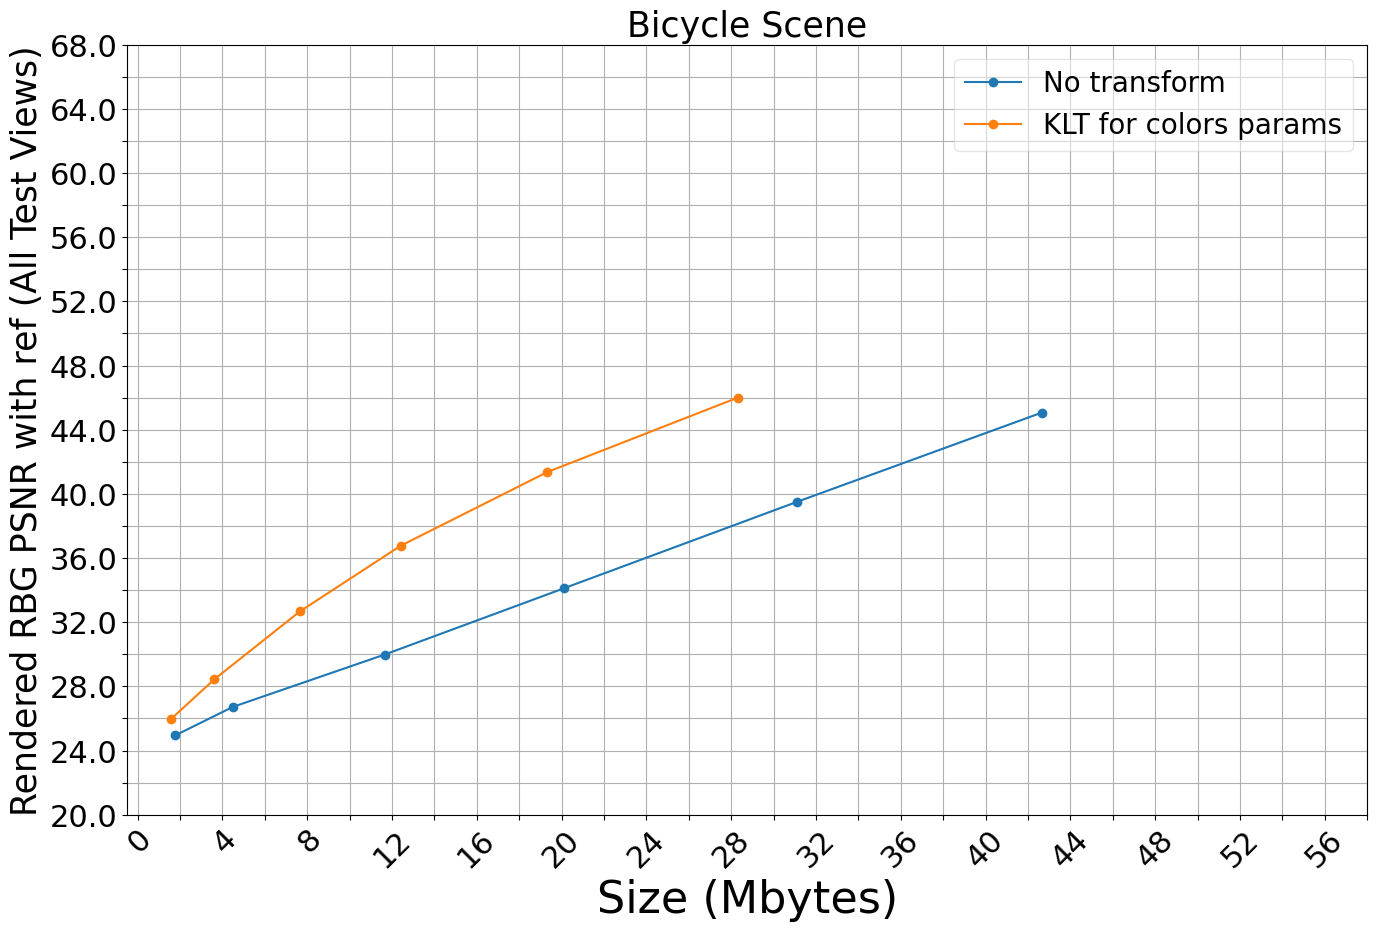

In [8]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 10))


## BASELINE 
list_mb=[42.65760775, 31.1264985, 20.129405375, 11.649713125, 4.490344, 1.782546625]
list_psnr=[45.069699879243956, 39.51526576837232, 34.12551402026903, 29.98319666743802, 26.72175350832743, 24.95274452824074]
ax.plot(list_mb, list_psnr, '-o', label="No transform")

list_mb=[28.302458375, 19.326980125, 12.402099125, 7.648794125, 3.622306375, 1.5582055]
list_psnr=[45.99759602691401, 41.36291191310904, 36.763762068188086, 32.66946422126016, 28.447847673938522, 25.948961947242786]
ax.plot(list_mb, list_psnr, '-o', label="KLT for colors params")


# ist_mb=[42.65760775, 31.1264985, 20.129405375, 11.649713125, 4.490344, 1.782546625]
# list_psnr=[45.069699879243956, 39.51526576837232, 34.12551402026903, 29.98319666743802, 26.72175350832743, 24.95274452824074]
# ax.plot(list_mb, list_psnr, '-o', label="Directional Transform + KLT on transformed coefs - View dependent picked")


############ 
plt.yticks(ticks=np.arange(20, 70, step=2), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 70, step=2))], fontsize=22)
plt.xticks(ticks=np.arange(0, 60, step=2), labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 60, step=2))], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Size (Mbytes)', fontsize=32)
plt.ylabel('Rendered RBG PSNR with ref (All Test Views)', fontsize=25)
plt.title('Bicycle Scene', fontsize=25)